In [ ]:
print(df_clean.shape)

print(df.shape)

#Sem duplicatas, 3 colunas adicionadas

(8807, 15)
(8807, 12)


In [ ]:
#Slvando dataset limpo
OUTPUT_PATH = "../data/processed/netflix_clean.csv"

df_clean.to_csv(
    OUTPUT_PATH,
    index=False
)

In [ ]:
#Novas colunas
#Ano

df_clean["year_added"] = (
    df_clean["date_added"]
    .dt.year
)

#Mês
df_clean["month_added"] = (
    df_clean["date_added"]
    .dt.month_name()
)

#Dia
df_clean["weekday_added"] = (
    df_clean["date_added"]
    .dt.day_name()
)

df_clean.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,weekday_added
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.00,September,Saturday
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.00,September,Friday
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.00,September,Friday
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.00,September,Friday
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.00,September,Friday


In [ ]:
#Converter data de objeto para datetime
df_clean["date_added"] = pd.to_datetime(
    df_clean["date_added"],
    errors="coerce"
)

df_clean["date_added"].head()
df_clean["date_added"].dtype

dtype('<M8[us]')

In [ ]:
#Espaços em branco
text_columns = df_clean.select_dtypes(include="object").columns

text_columns

#Removendo espaços em branco
for column in text_columns:
    df_clean[column] = (
        df_clean[column]
        .str.strip()
    )

In [ ]:
#Checando duplicatas
duplicates = df_clean.duplicated().sum()

print(f"Duplicated rows: {duplicates}")

Duplicated rows: 0


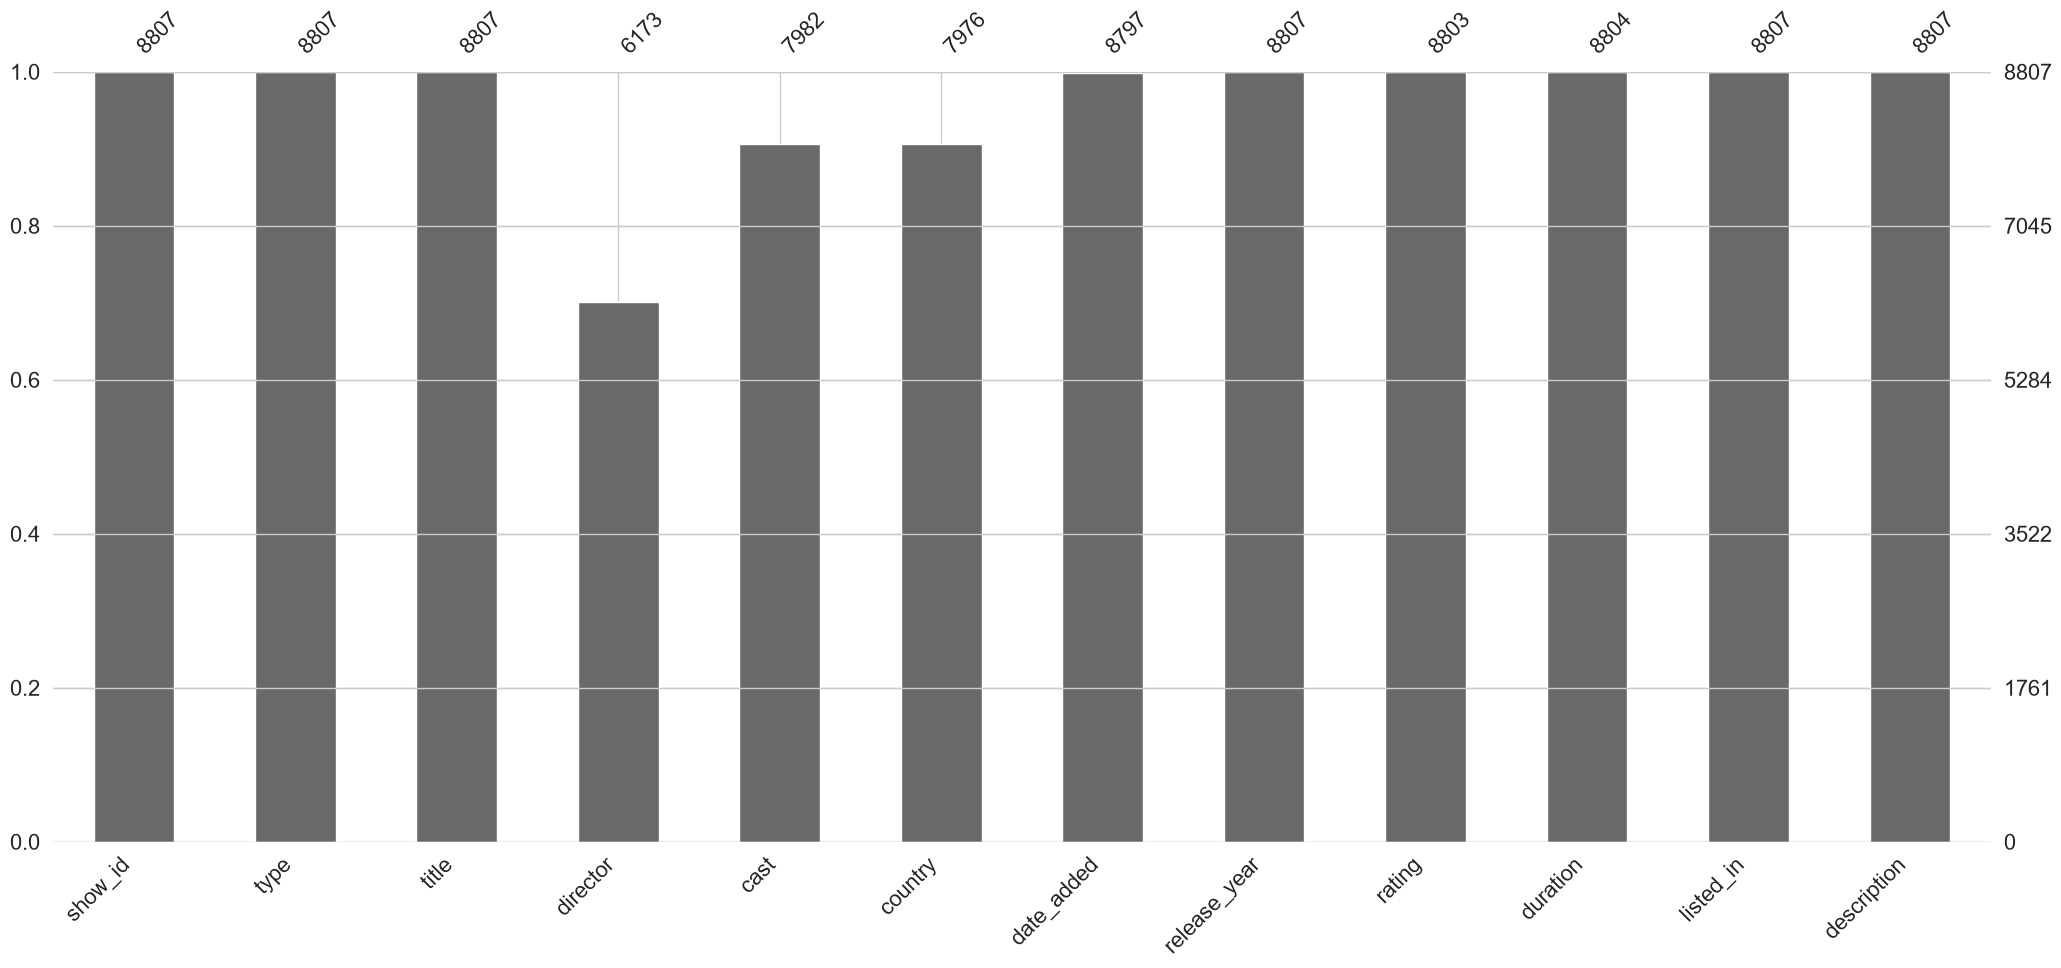

In [ ]:
#Bar plot

msno.bar(df_clean)

plt.show()

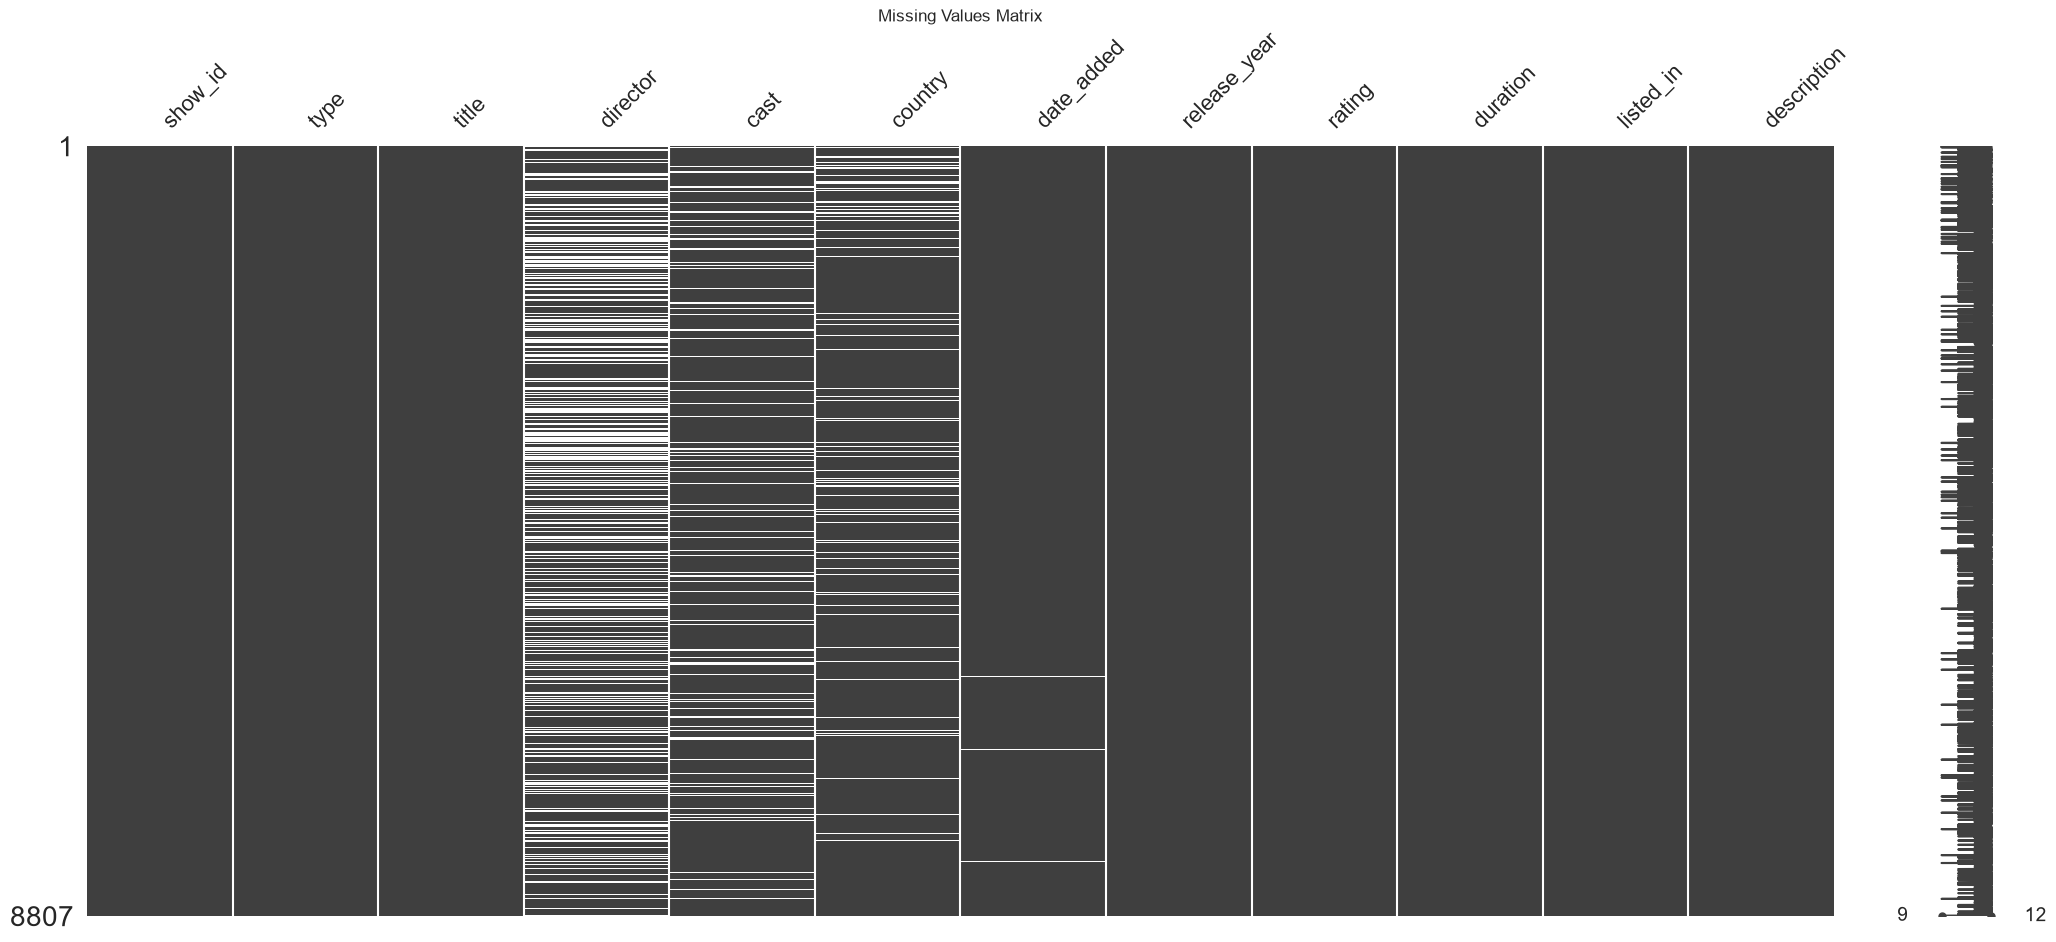

In [ ]:
#Visualização de data faltante

msno.matrix(df_clean)

plt.title("Missing Values Matrix")

plt.show()

In [ ]:
#Tabela completa

missing_table = pd.DataFrame({
    "Missing Values": df_clean.isna().sum(),
    "Percentage (%)": (
        df_clean
        .isna()
        .mean()
        .mul(100)
        .round(2)
    )
})

missing_table = missing_table.sort_values(
    by="Percentage (%)",
    ascending=False
)

missing_table

,Missing Values,Percentage (%)
director,2634,29.91
country,831,9.44
cast,825,9.37
date_added,10,0.11
rating,4,0.05
duration,3,0.03
show_id,0,0.00
type,0,0.00
title,0,0.00
release_year,0,0.00


In [ ]:
#Porcentagem de valores faltantes
missing_percent = (
    df_clean
    .isna()
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

missing_percent

director       29.91
country         9.44
cast            9.37
date_added      0.11
rating          0.05
duration        0.03
show_id         0.00
type            0.00
title           0.00
release_year    0.00
listed_in       0.00
description     0.00
dtype: float64

In [ ]:
missing = df_clean.isna().sum()

missing

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [4]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [ ]:
#Copia para manipulação
df_clean = df.copy()

In [2]:
DATASET_PATH = "../data/raw/netflix_titles.csv"

df = pd.read_csv(DATASET_PATH)

In [ ]:
#Configuração de ambiente
import warnings

import matplotlib.pyplot as plt
import missingno as msno
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)

##Data Cleaning

##Objetivos ##
- Avaliar a qualidade dos dados.
- Identificar valores ausentes.
- Remover duplicatas.
- Padronizar informações.
- Converter tipos de dados.
- Criar novas variáveis.
- Gerar um dataset limpo para as próximas análises.